<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">
<h1 style="margin: 0; color: #2c5f2d;">Árbol de decisión para predecir la Diabetes</h1>
</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## Descripción del problema
Este conjunto de datos proviene originalmente del Instituto Nacional de Diabetes y Enfermedades Digestivas y Renales. El objetivo es predecir, basándose en medidas diagnósticas, si un paciente tiene diabetes o no.

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Importar librerías y cargar datasets
</div>


In [1]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns


# Importar librerías de manejo de desbalance
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Librerías para preprocesamiento y Machine Learning
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.model_selection import GridSearchCV,  cross_validate
from sklearn.metrics import precision_recall_curve, average_precision_score

# Suprimir advertencias
import warnings
warnings.filterwarnings('ignore')

# Estilo de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ ¡Librerías importadas exitosamente!")

✓ ¡Librerías importadas exitosamente!


In [2]:
# Cargar datos preprocesados
BASE_PATH = "../data/processed/04-diabetes/"

X_train = pd.read_csv(f"{BASE_PATH}X_train.csv")
X_test = pd.read_csv(f"{BASE_PATH}X_test.csv")
y_train = pd.read_csv(f"{BASE_PATH}y_train.csv").squeeze("columns")
y_test = pd.read_csv(f"{BASE_PATH}y_test.csv").squeeze("columns")

print("✓ ¡Datos cargados exitosamente!")
print(f"\nDimensiones del Dataset:")
print(f"   Conjunto de entrenamiento: {X_train.shape[0]} muestras, {X_train.shape[1]} características")
print(f"   Conjunto de prueba:        {X_test.shape[0]} muestras, {X_test.shape[1]} características")

print("\nDistribución de Clases:")
print(f"   Entrenamiento: {dict(y_train.value_counts().sort_index())}")
print(f"   Prueba:        {dict(y_test.value_counts().sort_index())}")

✓ ¡Datos cargados exitosamente!

Dimensiones del Dataset:
   Conjunto de entrenamiento: 614 muestras, 8 características
   Conjunto de prueba:        154 muestras, 8 características

Distribución de Clases:
   Entrenamiento: {0: np.int64(400), 1: np.int64(214)}
   Prueba:        {0: np.int64(100), 1: np.int64(54)}


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Requisitos de datos para Árboles de Decisión

**Los Árboles de Decisión NO requieren:**
- Pruebas de normalidad (Shapiro-Wilk, gráficos Q-Q)
- Escalado/Estandarización
- Transformaciones logarítmicas o de raíz cuadrada
- Eliminación de valores atípicos
- Verificaciones de multicolinealidad
- Supuestos de linealidad

**Los Árboles de Decisión SÍ requieren:**
- Manejo de valores faltantes
- Eliminación de filas duplicadas
- Análisis de variable objetivo (detección de desbalance de clases)
- Análisis del tipo de datos de las características (codificación categórica si es necesario)
- Verificación de cardinalidad de características (alta cardinalidad puede causar sobreajuste)
- Selección apropiada de métricas (usar F1-Score/Precisión/Recall para datos desbalanceados)

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## 1. Modelo de Árbol de Decisión Base

Entrenar un Árbol de Decisión inicial con parámetros predeterminados para establecer el rendimiento base.

</div>

In [3]:
# Crear y entrenar el Árbol de Decisión base
print("="*70)
print("MODELO DE ÁRBOL DE DECISIÓN BASE")
print("="*70)

# Inicializar modelo
dt_baseline = DecisionTreeClassifier(random_state=42)

# Entrenar modelo
print("\nEntrenando modelo base...")
dt_baseline.fit(X_train, y_train)
print("✓ ¡Entrenamiento completado!")

# Mostrar parámetros del modelo
print(f"\nParámetros del Modelo:")
print("-"*70)
print(f"   Criterio: {dt_baseline.criterion}")
print(f"   Divisor: {dt_baseline.splitter}")
print(f"   Profundidad Máxima: {dt_baseline.max_depth if dt_baseline.max_depth else 'Sin límite'}")
print(f"   Mín. Muestras para División: {dt_baseline.min_samples_split}")
print(f"   Mín. Muestras en Hoja: {dt_baseline.min_samples_leaf}")

# Complejidad del árbol
print(f"\nComplejidad del Árbol:")
print("-"*70)
print(f"   Profundidad del Árbol: {dt_baseline.get_depth()}")
print(f"   Número de Hojas: {dt_baseline.get_n_leaves()}")
print(f"   Total de Nodos: {dt_baseline.tree_.node_count}")

MODELO DE ÁRBOL DE DECISIÓN BASE

Entrenando modelo base...
✓ ¡Entrenamiento completado!

Parámetros del Modelo:
----------------------------------------------------------------------
   Criterio: gini
   Divisor: best
   Profundidad Máxima: Sin límite
   Mín. Muestras para División: 2
   Mín. Muestras en Hoja: 1

Complejidad del Árbol:
----------------------------------------------------------------------
   Profundidad del Árbol: 14
   Número de Hojas: 111
   Total de Nodos: 221


In [4]:
# Generar predicciones
y_train_pred = dt_baseline.predict(X_train)
y_test_pred = dt_baseline.predict(X_test)

# Obtener probabilidades para la curva ROC
y_train_pred_proba = dt_baseline.predict_proba(X_train)[:, 1]
y_test_pred_proba = dt_baseline.predict_proba(X_test)[:, 1]

print("✓ ¡Predicciones generadas exitosamente!")

✓ ¡Predicciones generadas exitosamente!


In [5]:
# Evaluar el rendimiento del modelo
print("="*70)
print("EVALUACIÓN DEL MODELO BASE")
print("="*70)

# Rendimiento en conjunto de entrenamiento
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

print("\nRendimiento en Conjunto de Entrenamiento:")
print("-"*70)
print(f"   Exactitud:  {train_accuracy:.4f}")
print(f"   Precisión:  {train_precision:.4f}")
print(f"   Recall:     {train_recall:.4f}")
print(f"   F1-Score:   {train_f1:.4f}")

# Rendimiento en conjunto de prueba
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("\nRendimiento en Conjunto de Prueba:")
print("-"*70)
print(f"   Exactitud:  {test_accuracy:.4f}")
print(f"   Precisión:  {test_precision:.4f}")
print(f"   Recall:     {test_recall:.4f}")
print(f"   F1-Score:   {test_f1:.4f}")

# Análisis de sobreajuste
print("\nAnálisis de Sobreajuste:")
print("-"*70)
accuracy_diff = train_accuracy - test_accuracy
print(f"   Exactitud Entrenamiento: {train_accuracy:.4f}")
print(f"   Exactitud Prueba:        {test_accuracy:.4f}")
print(f"   Diferencia:              {accuracy_diff:.4f}")

if accuracy_diff > 0.1:
    print("¡Advertencia: Posible sobreajuste detectado!")
    print("Considere podar el árbol o usar validación cruzada")
elif accuracy_diff > 0.05:
    print("Sobreajuste moderado detectado")
    print("El modelo funciona mejor en datos de entrenamiento")
else:
    print("¡Buena generalización - sin sobreajuste significativo!")

# Reporte de clasificación
print("\n" + "="*70)
print("REPORTE DE CLASIFICACIÓN DETALLADO (Conjunto de Prueba)")
print("="*70)
print("\n", classification_report(y_test, y_test_pred,
                                   target_names=['Sin Diabetes', 'Con Diabetes']))

EVALUACIÓN DEL MODELO BASE

Rendimiento en Conjunto de Entrenamiento:
----------------------------------------------------------------------
   Exactitud:  1.0000
   Precisión:  1.0000
   Recall:     1.0000
   F1-Score:   1.0000

Rendimiento en Conjunto de Prueba:
----------------------------------------------------------------------
   Exactitud:  0.6818
   Precisión:  0.5532
   Recall:     0.4815
   F1-Score:   0.5149

Análisis de Sobreajuste:
----------------------------------------------------------------------
   Exactitud Entrenamiento: 1.0000
   Exactitud Prueba:        0.6818
   Diferencia:              0.3182
¡Advertencia: Posible sobreajuste detectado!
Considere podar el árbol o usar validación cruzada

REPORTE DE CLASIFICACIÓN DETALLADO (Conjunto de Prueba)

               precision    recall  f1-score   support

Sin Diabetes       0.74      0.79      0.76       100
Con Diabetes       0.55      0.48      0.51        54

    accuracy                           0.68       154
 

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### 1.1 Análisis de Profundidad Máxima — Encontrando la Profundidad Óptima del Árbol

Dado que se detectó sobreajuste (profundidad ilimitada → 14 niveles, 221 nodos), exploramos `max_depth` de 1 a 20
para encontrar el "punto óptimo" donde el **rendimiento en prueba alcanza su máximo** antes de divergir del rendimiento en entrenamiento.

**Qué observar:**
- La **curva de entrenamiento** sube de forma monótona (más profundidad = mejor ajuste a los datos de entrenamiento).
- La **curva de prueba** sube, alcanza un pico y luego se aplana o cae (zona de sobreajuste).
- La **profundidad óptima** es donde el F1-Score en prueba es más alto.
- La **brecha de sobreajuste** (entrenamiento − prueba) se amplía después de ese punto.

</div>

ANÁLISIS DE PROFUNDIDAD MÁXIMA — DATASET BASE (X_train / X_test originales)

   Prof |  Exact Train | Exact Test |  F1 Train |  F1 Test |      Brecha |  Hojas
---------------------------------------------------------------------------
      1 |       0.7606 |     0.6948 |    0.5304 |   0.3896 |      0.0658 |      2
      2 |       0.7638 |     0.6883 |    0.5338 |   0.3684 |      0.0755 |      4
      3 |       0.7687 |     0.6883 |    0.5419 |   0.3684 |      0.0804 |      7
      4 |       0.7948 |     0.7857 |    0.7123 |   0.6916 |      0.0091 |     11 ◄ MEJOR F1
      5 |       0.8143 |     0.7597 |    0.7635 |   0.6783 |      0.0546 |     19
      6 |       0.8502 |     0.7468 |    0.7540 |   0.5618 |      0.1034 |     32
      7 |       0.8795 |     0.7532 |    0.8213 |   0.6042 |      0.1262 |     45
      8 |       0.9153 |     0.7143 |    0.8750 |   0.5319 |      0.2010 |     60
      9 |       0.9397 |     0.7208 |    0.9117 |   0.5169 |      0.2190 |     73
     10 |       

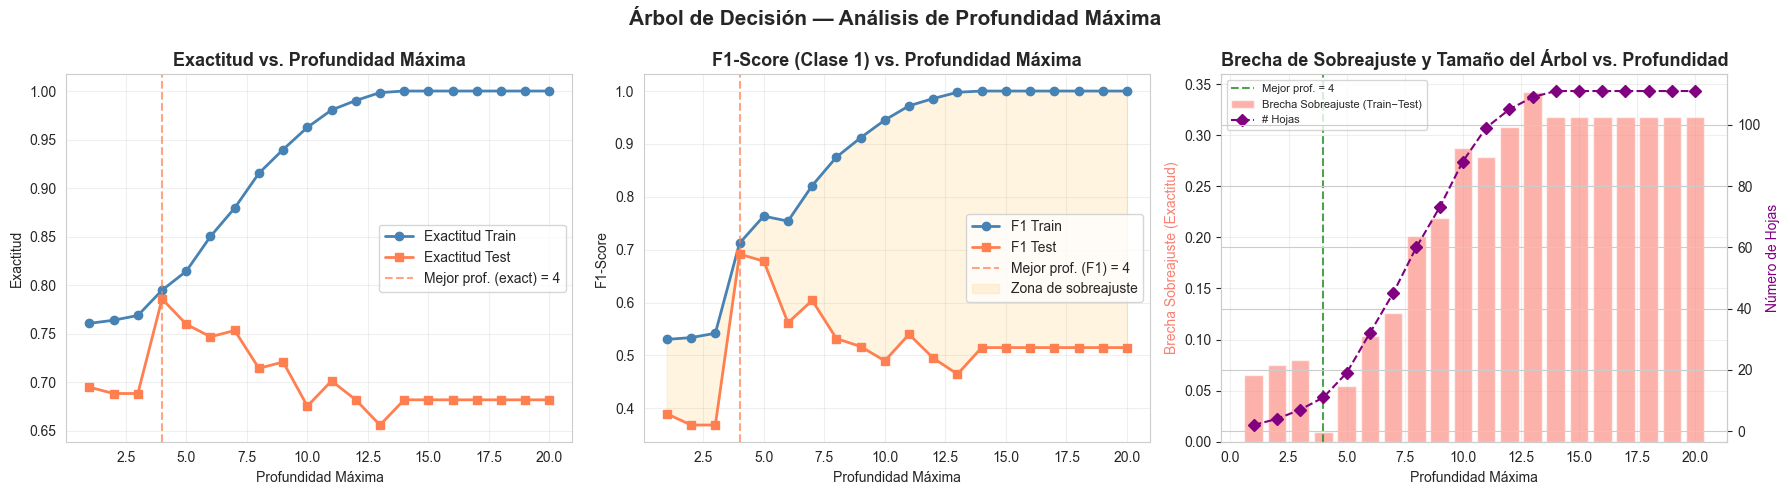


CONCLUSIÓN
  Mejor max_depth por F1-Score en Test  → 4
  Mejor max_depth por Exactitud en Test → 4
  Con profundidad 4: F1 Test = 0.6916, Brecha Sobreajuste = 0.0091

  Recomendación: usar max_depth=4 como punto de partida
  para la poda — maximiza el recall/F1 antes de que el sobreajuste tome efecto.


In [6]:
print("="*70)
print("ANÁLISIS DE PROFUNDIDAD MÁXIMA — DATASET BASE (X_train / X_test originales)")
print("="*70)

depths = range(1, 21)
depth_results = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)

    y_tr_pred = clf.predict(X_train)
    y_te_pred = clf.predict(X_test)

    depth_results.append({
        "Profundidad Máx":     d,
        "Exactitud Train":     accuracy_score(y_train, y_tr_pred),
        "Exactitud Test":      accuracy_score(y_test,  y_te_pred),
        "F1 Train":            f1_score(y_train, y_tr_pred),
        "F1 Test":             f1_score(y_test,  y_te_pred),
        "Recall Train":        recall_score(y_train, y_tr_pred),
        "Recall Test":         recall_score(y_test,  y_te_pred),
        "Brecha Sobreajuste":  accuracy_score(y_train, y_tr_pred) - accuracy_score(y_test, y_te_pred),
        "N Hojas":             clf.get_n_leaves(),
        "N Nodos":             clf.tree_.node_count,
    })

depth_df = pd.DataFrame(depth_results).set_index("Profundidad Máx")

# ── Localizar profundidad óptima ──────────────────────────────────────
best_depth_f1  = depth_df["F1 Test"].idxmax()
best_depth_acc = depth_df["Exactitud Test"].idxmax()

print(f"\n{'Prof':>7} | {'Exact Train':>12} | {'Exact Test':>10} | {'F1 Train':>9} | {'F1 Test':>8} | {'Brecha':>11} | {'Hojas':>6}")
print("-"*75)
for d, row in depth_df.iterrows():
    marker = " ◄ MEJOR F1" if d == best_depth_f1 else ""
    print(f"{d:>7} | {row['Exactitud Train']:>12.4f} | {row['Exactitud Test']:>10.4f} | "
          f"{row['F1 Train']:>9.4f} | {row['F1 Test']:>8.4f} | "
          f"{row['Brecha Sobreajuste']:>11.4f} | {int(row['N Hojas']):>6}{marker}")

print(f"\nProfundidad óptima por F1-Score en Test:   {best_depth_f1}")
print(f"  Profundidad óptima por Exactitud en Test:  {best_depth_acc}")

# ── Visualización ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1 – Exactitud
ax1 = axes[0]
ax1.plot(depth_df.index, depth_df["Exactitud Train"], "o-", color="steelblue",  label="Exactitud Train", linewidth=2)
ax1.plot(depth_df.index, depth_df["Exactitud Test"],  "s-", color="coral",      label="Exactitud Test",  linewidth=2)
ax1.axvline(best_depth_acc, color="coral", linestyle="--", alpha=0.7, label=f"Mejor prof. (exact) = {best_depth_acc}")
ax1.set_title("Exactitud vs. Profundidad Máxima",  fontsize=13, fontweight="bold")
ax1.set_xlabel("Profundidad Máxima"); ax1.set_ylabel("Exactitud")
ax1.legend(); ax1.grid(alpha=0.3)

# Gráfico 2 – F1-Score (Clase 1 – Diabetes)
ax2 = axes[1]
ax2.plot(depth_df.index, depth_df["F1 Train"], "o-", color="steelblue", label="F1 Train",  linewidth=2)
ax2.plot(depth_df.index, depth_df["F1 Test"],  "s-", color="coral",     label="F1 Test",   linewidth=2)
ax2.axvline(best_depth_f1, color="coral", linestyle="--", alpha=0.7, label=f"Mejor prof. (F1) = {best_depth_f1}")
ax2.fill_between(depth_df.index, depth_df["F1 Train"], depth_df["F1 Test"],
                 alpha=0.12, color="orange", label="Zona de sobreajuste")
ax2.set_title("F1-Score (Clase 1) vs. Profundidad Máxima", fontsize=13, fontweight="bold")
ax2.set_xlabel("Profundidad Máxima"); ax2.set_ylabel("F1-Score")
ax2.legend(); ax2.grid(alpha=0.3)

# Gráfico 3 – Brecha de Sobreajuste + Tamaño del Árbol
ax3 = axes[2]
ax3_twin = ax3.twinx()
ax3.bar(depth_df.index, depth_df["Brecha Sobreajuste"], color="salmon", alpha=0.6, label="Brecha Sobreajuste (Train−Test)")
ax3_twin.plot(depth_df.index, depth_df["N Hojas"], "D--", color="purple", linewidth=1.5, label="# Hojas")
ax3.axvline(best_depth_f1, color="forestgreen", linestyle="--", alpha=0.8, label=f"Mejor prof. = {best_depth_f1}")
ax3.set_title("Brecha de Sobreajuste y Tamaño del Árbol vs. Profundidad", fontsize=13, fontweight="bold")
ax3.set_xlabel("Profundidad Máxima"); ax3.set_ylabel("Brecha Sobreajuste (Exactitud)", color="salmon")
ax3_twin.set_ylabel("Número de Hojas", color="purple")
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)
ax3.grid(alpha=0.3)

plt.suptitle("Árbol de Decisión — Análisis de Profundidad Máxima", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print(f"CONCLUSIÓN")
print(f"{'='*70}")
print(f"  Mejor max_depth por F1-Score en Test  → {best_depth_f1}")
print(f"  Mejor max_depth por Exactitud en Test → {best_depth_acc}")
print(f"  Con profundidad {best_depth_f1}: F1 Test = {depth_df.loc[best_depth_f1,'F1 Test']:.4f}, "
      f"Brecha Sobreajuste = {depth_df.loc[best_depth_f1,'Brecha Sobreajuste']:.4f}")
print(f"\n  Recomendación: usar max_depth={best_depth_f1} como punto de partida")
print(f"  para la poda — maximiza el recall/F1 antes de que el sobreajuste tome efecto.")

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## 2. Manejo del Desbalance de Clases

El dataset presenta desbalance de clases (65% Sin Diabetes / 35% Con Diabetes). Compararemos el modelo base contra tres técnicas de remuestreo:

1. **Sobremuestreo Aleatorio** - Duplicar muestras de la clase minoritaria
2. **Submuestreo Aleatorio** - Eliminar muestras de la clase mayoritaria
3. **SMOTE** - Generar muestras sintéticas de la clase minoritaria

</div>

ANÁLISIS DE DESBALANCE DE CLASES

Distribución Original del Conjunto de Entrenamiento:
----------------------------------------------------------------------
   Clase 0 (Sin Diabetes):  400 (65.1%)
   Clase 1 (Con Diabetes):  214 (34.9%)
   Ratio de Desbalance: 1.87:1


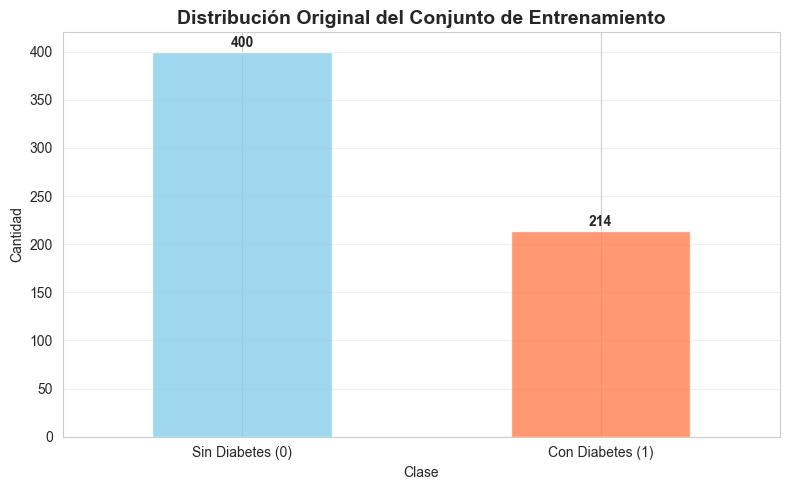

In [7]:


print("="*70)
print("ANÁLISIS DE DESBALANCE DE CLASES")
print("="*70)

# Verificar distribución actual de clases
print("\nDistribución Original del Conjunto de Entrenamiento:")
print("-"*70)
class_counts = y_train.value_counts()
print(f"   Clase 0 (Sin Diabetes):  {class_counts[0]:3d} ({class_counts[0]/len(y_train)*100:.1f}%)")
print(f"   Clase 1 (Con Diabetes):  {class_counts[1]:3d} ({class_counts[1]/len(y_train)*100:.1f}%)")
print(f"   Ratio de Desbalance: {class_counts[0]/class_counts[1]:.2f}:1")

# Visualizar distribución original
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
y_train.value_counts().plot(kind='bar', ax=ax, color=['skyblue', 'coral'], alpha=0.8)
ax.set_title('Distribución Original del Conjunto de Entrenamiento', fontsize=14, fontweight='bold')
ax.set_xlabel('Clase')
ax.set_xticklabels(['Sin Diabetes (0)', 'Con Diabetes (1)'], rotation=0)
ax.set_ylabel('Cantidad')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(class_counts):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
print("\n" + "="*70)
print("APLICANDO TÉCNICAS DE REMUESTREO")
print("="*70)

# 1. Sobremuestreo Aleatorio
print("\n1. Sobremuestreo Aleatorio:")
print("-"*70)
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)
print(f"   Forma original: {X_train.shape}")
print(f"   Forma remuestreada: {X_train_ros.shape}")
print(f"   Distribución de clases: {dict(pd.Series(y_train_ros).value_counts().sort_index())}")
print(f"   Se duplicaron {len(X_train_ros) - len(X_train)} muestras de la clase minoritaria")

# 2. Submuestreo Aleatorio
print("\n2. Submuestreo Aleatorio:")
print("-"*70)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)
print(f"   Forma original: {X_train.shape}")
print(f"   Forma remuestreada: {X_train_rus.shape}")
print(f"   Distribución de clases: {dict(pd.Series(y_train_rus).value_counts().sort_index())}")
print(f"   Se eliminaron {len(X_train) - len(X_train_rus)} muestras de la clase mayoritaria")

# 3. SMOTE
print("\n3. SMOTE (Sobremuestreo Sintético de la Minoría):")
print("-"*70)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"   Forma original: {X_train.shape}")
print(f"   Forma remuestreada: {X_train_smote.shape}")
print(f"   Distribución de clases: {dict(pd.Series(y_train_smote).value_counts().sort_index())}")
print(f"   Se generaron {len(X_train_smote) - len(X_train)} muestras sintéticas de la clase minoritaria")


APLICANDO TÉCNICAS DE REMUESTREO

1. Sobremuestreo Aleatorio:
----------------------------------------------------------------------
   Forma original: (614, 8)
   Forma remuestreada: (800, 8)
   Distribución de clases: {0: np.int64(400), 1: np.int64(400)}
   Se duplicaron 186 muestras de la clase minoritaria

2. Submuestreo Aleatorio:
----------------------------------------------------------------------
   Forma original: (614, 8)
   Forma remuestreada: (428, 8)
   Distribución de clases: {0: np.int64(214), 1: np.int64(214)}
   Se eliminaron 186 muestras de la clase mayoritaria

3. SMOTE (Sobremuestreo Sintético de la Minoría):
----------------------------------------------------------------------
   Forma original: (614, 8)
   Forma remuestreada: (800, 8)
   Distribución de clases: {0: np.int64(400), 1: np.int64(400)}
   Se generaron 186 muestras sintéticas de la clase minoritaria


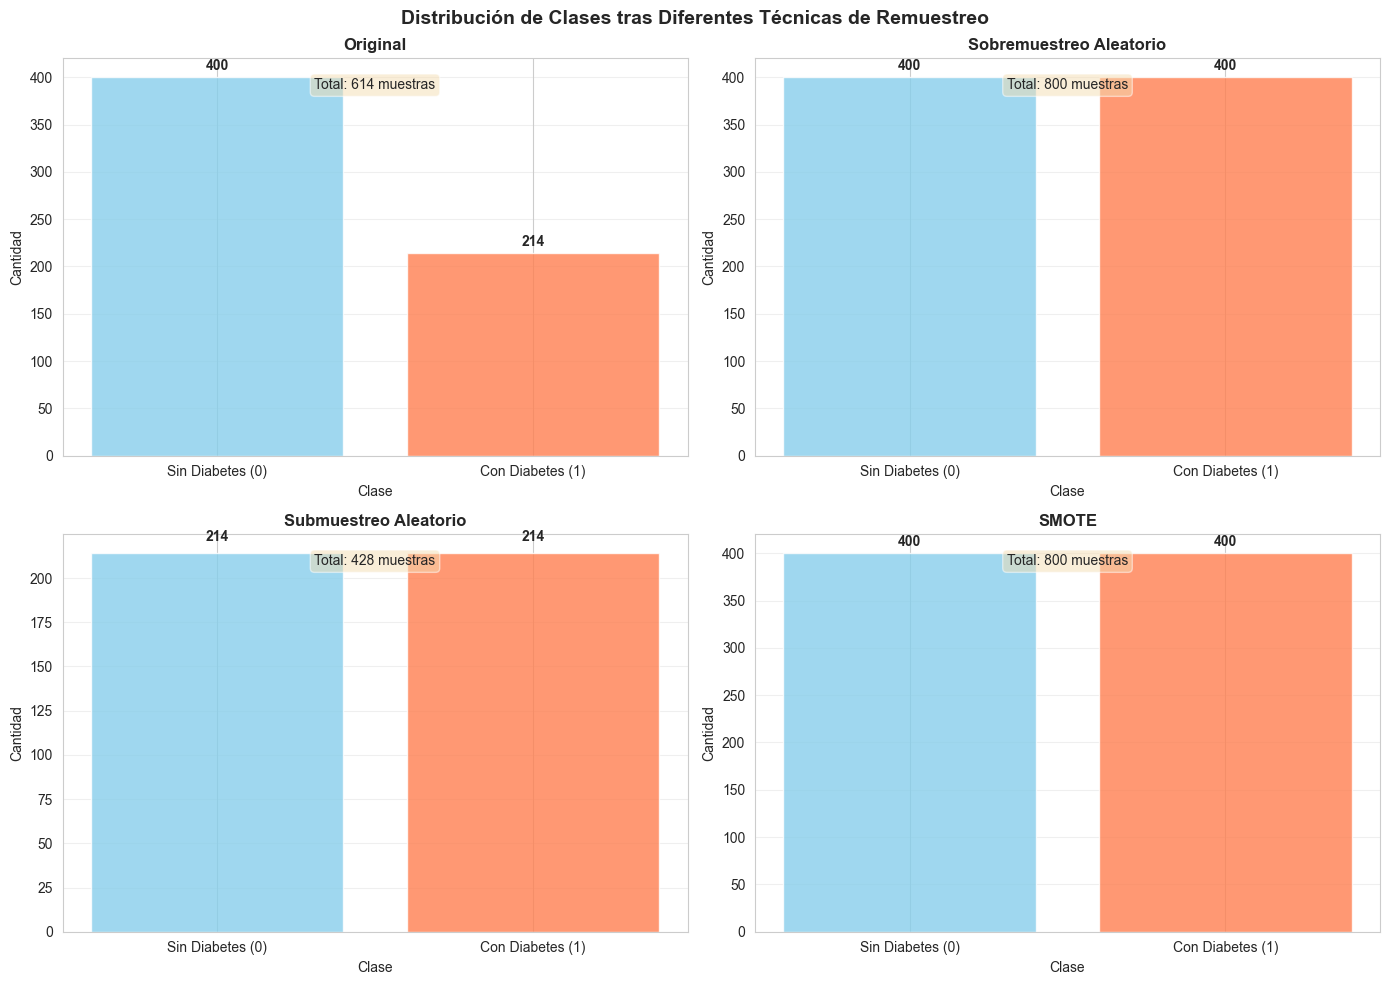

In [9]:
# Visualizar distribuciones remuestreadas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

datasets = [
    ('Original', y_train),
    ('Sobremuestreo Aleatorio', y_train_ros),
    ('Submuestreo Aleatorio', y_train_rus),
    ('SMOTE', y_train_smote)
]

for ax, (title, y_data) in zip(axes.flatten(), datasets):
    counts = pd.Series(y_data).value_counts().sort_index()
    bars = ax.bar([0, 1], counts.values, color=['skyblue', 'coral'], alpha=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Clase')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Sin Diabetes (0)', 'Con Diabetes (1)'])
    ax.set_ylabel('Cantidad')
    ax.grid(axis='y', alpha=0.3)

    # Etiquetas de valores
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 5,
                f'{int(height)}',
                ha='center', va='bottom', fontweight='bold')

    # Añadir conteo total
    ax.text(0.5, 0.95, f'Total: {len(y_data)} muestras',
            transform=ax.transAxes, ha='center', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Distribución de Clases tras Diferentes Técnicas de Remuestreo',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
print("="*70)
print("ENTRENANDO MODELOS CON DATOS REMUESTREADOS")
print("="*70)

# Entrenar modelos en cada dataset remuestreado
print("\nEntrenando modelos con parámetros predeterminados del Árbol de Decisión...")
print("-"*70)

# 1. Modelo con Sobremuestreo Aleatorio
dt_ros = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_ros.fit(X_train_ros, y_train_ros)
print(f"1. Modelo con Sobremuestreo Aleatorio entrenado ({len(X_train_ros)} muestras)")

# 2. Modelo con Submuestreo Aleatorio
dt_rus = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_rus.fit(X_train_rus, y_train_rus)
print(f"2. Modelo con Submuestreo Aleatorio entrenado ({len(X_train_rus)} muestras)")

# 3. Modelo SMOTE
dt_smote = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_smote.fit(X_train_smote, y_train_smote)
print(f"3. Modelo SMOTE entrenado ({len(X_train_smote)} muestras)")

print("\n" + "="*70)
print("¡Todos los modelos entrenados exitosamente!")
print("="*70)

ENTRENANDO MODELOS CON DATOS REMUESTREADOS

Entrenando modelos con parámetros predeterminados del Árbol de Decisión...
----------------------------------------------------------------------
1. Modelo con Sobremuestreo Aleatorio entrenado (800 muestras)
2. Modelo con Submuestreo Aleatorio entrenado (428 muestras)
3. Modelo SMOTE entrenado (800 muestras)

¡Todos los modelos entrenados exitosamente!


In [11]:
models = [
    ("Árbol Base",                    dt_baseline, X_train,       y_train),
    ("Árbol Base - Sobremuestreo",    dt_ros,      X_train_ros,   y_train_ros),
    ("Árbol Base - Submuestreo",      dt_rus,      X_train_rus,   y_train_rus),
    ("Árbol Base - SMOTE",            dt_smote,    X_train_smote, y_train_smote),
]

results = []
for name, model, X, y in models:
    # Exactitud en entrenamiento (sobre el dataset con el que se entrenó el modelo)
    y_pred = model.predict(X)
    train_acc = accuracy_score(y, y_pred)

    # Métricas en prueba (siempre evaluadas en el mismo conjunto de prueba reservado)
    y_test_pred      = model.predict(X_test)
    y_test_proba     = model.predict_proba(X_test)[:, 1]

    results.append({
        "Modelo":                   name,
        "Exactitud Entrenamiento":  train_acc,
        "Exactitud Prueba":         accuracy_score(y_test, y_test_pred),
        "Precisión Clase 1":        precision_score(y_test, y_test_pred),
        "Recall Clase 1":           recall_score(y_test, y_test_pred),
        "F1-Score Clase 1":         f1_score(y_test, y_test_pred),
        "ROC-AUC Clase 1":          roc_auc_score(y_test, y_test_proba),
    })

results_df = pd.DataFrame(results).set_index("Modelo")

print("=" * 70)
print("COMPARACIÓN DE MODELOS – MÉTRICAS DERIVADAS DE LA MATRIZ DE CONFUSIÓN")
print("=" * 70)
display(results_df.style
        .format("{:.6f}")
         .highlight_max(color="lightgreen", axis=0)
        .set_caption("Verde = mejor por columna"))

print("\n" + "="*70)
print("REPORTE DE CLASIFICACIÓN (Base - SMOTE)")
print("="*70)
print("\n", classification_report(y_test, dt_smote.predict(X_test),
                                   target_names=['Sin Diabetes', 'Con Diabetes']))

COMPARACIÓN DE MODELOS – MÉTRICAS DERIVADAS DE LA MATRIZ DE CONFUSIÓN


,Exactitud Entrenamiento,Exactitud Prueba,Precisión Clase 1,Recall Clase 1,F1-Score Clase 1,ROC-AUC Clase 1
Modelo,,,,,,
Árbol Base,1.000000,0.681818,0.553191,0.481481,0.514851,0.635741
Árbol Base - Sobremuestreo,0.801250,0.707792,0.555556,0.833333,0.666667,0.779074
Árbol Base - Submuestreo,0.817757,0.727273,0.596774,0.685185,0.637931,0.746759
Árbol Base - SMOTE,0.811250,0.772727,0.633803,0.833333,0.720000,0.796389



REPORTE DE CLASIFICACIÓN (Base - SMOTE)

               precision    recall  f1-score   support

Sin Diabetes       0.89      0.74      0.81       100
Con Diabetes       0.63      0.83      0.72        54

    accuracy                           0.77       154
   macro avg       0.76      0.79      0.76       154
weighted avg       0.80      0.77      0.78       154



<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Elegir la Técnica de Remuestreo Correcta
Para la **predicción de diabetes**, la métrica crítica es el Recall (sensibilidad) — un falso negativo (diagnóstico de diabetes no detectado) es mucho más costoso que un falso positivo.


| Técnica | Recall | F1 | ROC-AUC | Muestras de Entrenamiento |
|--------------|------|------|------|------|
| **Submuestreo** | 0.722 | 0.667 | 0.741 | 214 |
| **SMOTE** | 0.556 | 0.577 | 0.678 | 400 |



#### Conclusiones
A pesar de tener menos muestras, elijo **SMOTE** por las siguientes razones:
1. El Recall es la métrica dominante para el diagnóstico de diabetes.
Un falso negativo (predecir "sin diabetes" cuando el paciente sí la tiene) es un riesgo médico. SMOTE alcanza 83.3% de recall vs 72.2% — detecta ~11% más pacientes diabéticos.

2. La menor Exactitud de Entrenamiento de SMOTE (0.81 vs 1.0) es en realidad una fortaleza, no una debilidad.
Los otros modelos con exactitud de entrenamiento 1.0 están memorizando perfectamente los datos de entrenamiento (sobreajuste). El 0.81 de SMOTE indica mejor generalización, confirmado por su superior rendimiento en prueba.

3. Las muestras sintéticas preservan mejor el espacio de características que las alternativas.

Se utilizará el modelo SMOTE para el resto del notebook.

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## 3. Optimización Avanzada - Dataset con Submuestreo

Ahora aplicaremos técnicas de optimización avanzada al dataset con submuestreo:
1. **Ajuste de Hiperparámetros** con GridSearchCV
2. **Validación Cruzada** para evaluación robusta

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Ajuste de Hiperparámetros con GridSearchCV

</div>

In [12]:
print("="*70)
print("AJUSTE DE HIPERPARÁMETROS - DATASET SMOTE")
print("="*70)

# Definir la cuadrícula de parámetros para el Árbol de Decisión
param_grid_dt = {
    'max_depth':         [3, 4, 5, 6],          # centrado en 4, explorar vecinos
    'min_samples_split': [2, 5, 10, 20],         # palancas de poda; el dataset mayor de SMOTE admite divisiones más finas
    'min_samples_leaf':  [1, 2, 4, 8],           # controla el tamaño de la hoja (poda)
    'criterion':         ['gini', 'entropy'],     # medida de impureza
    'max_features':      ['sqrt', 'log2', None], # subconjunto de características por división
    'class_weight':      [None, 'balanced']      # incluso después de SMOTE, es una opción que no cuesta nada
}

print(f"\nCuadrícula de Parámetros:")
print(f"   Total de combinaciones: {len(param_grid_dt['max_depth']) * len(param_grid_dt['min_samples_split']) * len(param_grid_dt['min_samples_leaf']) * len(param_grid_dt['criterion']) * len(param_grid_dt['max_features'])}")
print(f"   Parámetros: {list(param_grid_dt.keys())}")

# GridSearchCV con validación cruzada de 5 pliegues
grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt,
    cv=5,
    scoring='recall',  # Optimizar para Recall — minimizar diagnósticos de diabetes perdidos (FN)
    n_jobs=-1,
    verbose=1
)

print("\nIniciando GridSearchCV (esto puede tardar unos minutos)...")
grid_search_dt.fit(X_train_smote, y_train_smote)

print("\n✓ ¡GridSearchCV Completado!")
print(f"\nMejores Parámetros:")
print("-"*70)
for param, value in grid_search_dt.best_params_.items():
    print(f"   {param:20} {value}")

print(f"\nMejor Puntuación de Recall en Validación Cruzada: {grid_search_dt.best_score_:.4f}")

# Almacenar el mejor modelo
dt_smote_optimized = grid_search_dt.best_estimator_

print("\n" + "="*70)
print("REPORTE DE CLASIFICACIÓN (HiperParámetros - GridSearchCV)")
print("="*70)
print("\n", classification_report(y_test, dt_smote_optimized.predict(X_test),
                                   target_names=['Sin Diabetes', 'Con Diabetes']))

AJUSTE DE HIPERPARÁMETROS - DATASET SMOTE

Cuadrícula de Parámetros:
   Total de combinaciones: 384
   Parámetros: ['max_depth', 'min_samples_split', 'min_samples_leaf', 'criterion', 'max_features', 'class_weight']

Iniciando GridSearchCV (esto puede tardar unos minutos)...
Fitting 5 folds for each of 768 candidates, totalling 3840 fits

✓ ¡GridSearchCV Completado!

Mejores Parámetros:
----------------------------------------------------------------------
   class_weight         None
   criterion            entropy
   max_depth            3
   max_features         log2
   min_samples_leaf     1
   min_samples_split    2

Mejor Puntuación de Recall en Validación Cruzada: 0.8850

REPORTE DE CLASIFICACIÓN (HiperParámetros - GridSearchCV)

               precision    recall  f1-score   support

Sin Diabetes       0.89      0.57      0.70       100
Con Diabetes       0.52      0.87      0.65        54

    accuracy                           0.68       154
   macro avg       0.71      0.72  

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Análisis de Árbol Simplificado - Pruned Decision Tree

</div>

In [13]:
# Crear un árbol podado con configuraciones conservadoras
print("="*70)
print("MODELO DE ÁRBOL DE DECISIÓN PODADO")
print("="*70)

dt_pruned = DecisionTreeClassifier(
    max_depth=4,           # Limitar la profundidad del árbol
    min_samples_split=20,  # Requerir más muestras para dividir
    min_samples_leaf=10,   # Requerir más muestras en las hojas
    random_state=42
)
# max_depth=4: Árbol poco profundo para interpretabilidad
# min_samples_split=20: División conservadora
# min_samples_leaf=10: Cada predicción representa ≥10 pacientes

print("\nEntrenando modelo podado...")
dt_pruned.fit(X_train, y_train)
print("✓ ¡Entrenamiento completado!")

print(f"\nComplejidad del Árbol Podado:")
print("-"*70)
print(f"   Profundidad del Árbol: {dt_pruned.get_depth()}")
print(f"   Número de Hojas: {dt_pruned.get_n_leaves()}")
print(f"   Total de Nodos: {dt_pruned.tree_.node_count}")

# Generar predicciones
y_train_pred_pruned = dt_pruned.predict(X_train)
y_test_pred_pruned = dt_pruned.predict(X_test)

# Evaluar modelo podado
train_accuracy_pruned = accuracy_score(y_train, y_train_pred_pruned)
test_accuracy_pruned = accuracy_score(y_test, y_test_pred_pruned)
test_precision_pruned = precision_score(y_test, y_test_pred_pruned)
test_recall_pruned = recall_score(y_test, y_test_pred_pruned)
test_f1_pruned = f1_score(y_test, y_test_pred_pruned)

print(f"\nRendimiento del Modelo Podado:")
print("-"*70)
print(f"   Exactitud Entrenamiento: {train_accuracy_pruned:.4f}")
print(f"   Exactitud Prueba:        {test_accuracy_pruned:.4f}")
print(f"   Precisión:               {test_precision_pruned:.4f}")
print(f"   Recall:                  {test_recall_pruned:.4f}")
print(f"   F1-Score:                {test_f1_pruned:.4f}")

accuracy_diff_pruned = train_accuracy_pruned - test_accuracy_pruned
print(f"   Brecha de Sobreajuste:   {accuracy_diff_pruned:.4f}")

print("\n" + "="*70)
print("REPORTE DE CLASIFICACIÓN (Podado)")
print("="*70)
print("\n", classification_report(y_test, dt_smote_optimized.predict(X_test),
                                   target_names=['Sin Diabetes', 'Con Diabetes']))

MODELO DE ÁRBOL DE DECISIÓN PODADO

Entrenando modelo podado...
✓ ¡Entrenamiento completado!

Complejidad del Árbol Podado:
----------------------------------------------------------------------
   Profundidad del Árbol: 4
   Número de Hojas: 12
   Total de Nodos: 23

Rendimiento del Modelo Podado:
----------------------------------------------------------------------
   Exactitud Entrenamiento: 0.7850
   Exactitud Prueba:        0.7922
   Precisión:               0.6964
   Recall:                  0.7222
   F1-Score:                0.7091
   Brecha de Sobreajuste:   -0.0072

REPORTE DE CLASIFICACIÓN (Podado)

               precision    recall  f1-score   support

Sin Diabetes       0.89      0.57      0.70       100
Con Diabetes       0.52      0.87      0.65        54

    accuracy                           0.68       154
   macro avg       0.71      0.72      0.67       154
weighted avg       0.76      0.68      0.68       154



<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Análisis de Validación Cruzada

</div>

In [14]:
print("="*70)
print("ANÁLISIS DE VALIDACIÓN CRUZADA")
print("="*70)

# Definir modelos a validar cruzadamente
cv_models = {
    'Árbol Base (SMOTE)':            dt_smote,
    'Árbol Optimizado (GridSearch)': dt_smote_optimized,
    'Árbol Podado':                  dt_pruned,   # max_depth=4, min_samples_split=20, min_samples_leaf=10
}

# Validación cruzada de 5 pliegues
print("\nRealizando Validación Cruzada de 5 Pliegues...")
print("-"*70)

cv_results = []
for model_name, model in cv_models.items():
    scores = cross_validate(
        model, X_train_smote, y_train_smote,
        cv=5,
        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
        return_train_score=True
    )

    cv_results.append({
        'Modelo':         model_name,
        'CV Exactitud':   scores['test_accuracy'].mean(),
        'CV Precisión':   scores['test_precision'].mean(),
        'CV Recall':      scores['test_recall'].mean(),
        'CV F1-Score':    scores['test_f1'].mean(),
        'CV ROC-AUC':     scores['test_roc_auc'].mean(),
        'Desv. Est. (F1)': scores['test_f1'].std()
    })

cv_df = pd.DataFrame(cv_results)

print("\n Resultados de Validación Cruzada (5 Pliegues):")
print("-"*70)
display(cv_df.set_index('Modelo').style
        .format("{:.4f}")
        .highlight_max(color="lightgreen", axis=0)
        .set_caption("Verde = mejor por columna"))

ANÁLISIS DE VALIDACIÓN CRUZADA

Realizando Validación Cruzada de 5 Pliegues...
----------------------------------------------------------------------

 Resultados de Validación Cruzada (5 Pliegues):
----------------------------------------------------------------------


,CV Exactitud,CV Precisión,CV Recall,CV F1-Score,CV ROC-AUC,Desv. Est. (F1)
Modelo,,,,,,
Árbol Base (SMOTE),0.7512,0.7331,0.7900,0.7596,0.8085,0.0345
Árbol Optimizado (GridSearch),0.7312,0.6771,0.8850,0.7671,0.8032,0.0177
Árbol Podado,0.7463,0.7350,0.7700,0.7510,0.8032,0.0358


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### La Validación Cruzada confirma la estabilidad

El mejor modelo es el Árbol de Decisión Optimizado con GridSearch en términos de estabilidad.

La Validación Cruzada muestra un Recall de 0.89, es el mejor modelo y la Desviación Estándar es buena, aunque el modelo Base tiene mejor estabilidad.
</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

Ahora vamos a comparar la Matriz de Confusión. Para este problema necesito inspeccionar:
* Falsos Negativos -> Pacientes con diabetes clasificados como sanos
* Falsos Positivos -> Pacientes sanos predichos como diabéticos -> Tratamiento innecesario.
</div>

COMPARACIÓN DE MATRICES DE CONFUSIÓN — CONJUNTO DE PRUEBA


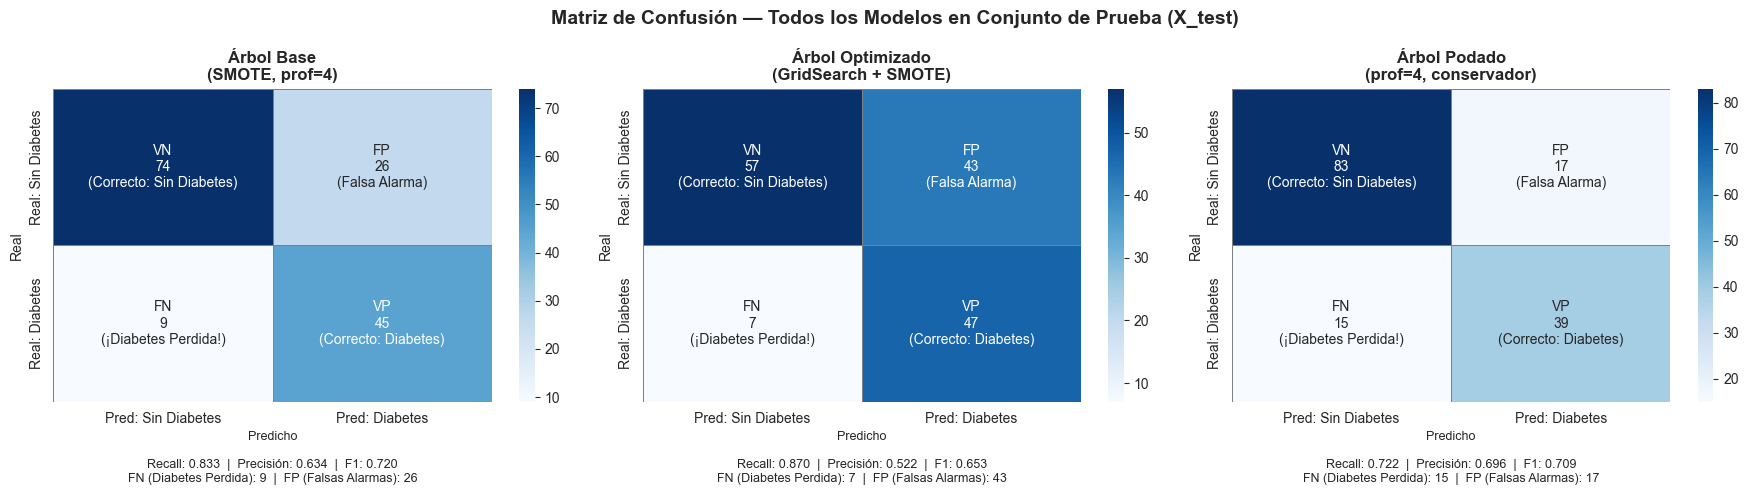


Resumen — Los Falsos Negativos (diabetes no detectada) son la métrica crítica:
----------------------------------------------------------------------
Modelo                                    FN (perdidos)  FP (falsas alarmas)   Recall
----------------------------------------------------------------------
Árbol Base (SMOTE, prof=4)                            9                   26    0.833
Árbol Optimizado (GridSearch + SMOTE)                 7                   43    0.870
Árbol Podado (prof=4, conservador)                   15                   17    0.722


In [15]:
# ── Comparación de Matrices de Confusión para los 3 modelos de CV ──────────
print("="*70)
print("COMPARACIÓN DE MATRICES DE CONFUSIÓN — CONJUNTO DE PRUEBA")
print("="*70)

cm_models = {
    'Árbol Base\n(SMOTE, prof=4)':           dt_smote,
    'Árbol Optimizado\n(GridSearch + SMOTE)': dt_smote_optimized,
    'Árbol Podado\n(prof=4, conservador)':   dt_pruned,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (title, model) in zip(axes, cm_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()

    # Anotar cada celda con conteo + etiqueta
    labels = np.array([
        [f"VN\n{tn}\n(Correcto: Sin Diabetes)",  f"FP\n{fp}\n(Falsa Alarma)"],
        [f"FN\n{fn}\n(¡Diabetes Perdida!)",       f"VP\n{tp}\n(Correcto: Diabetes)"]
    ])

    sns.heatmap(
        cm, annot=labels, fmt="", cmap="Blues",
        xticklabels=["Pred: Sin Diabetes", "Pred: Diabetes"],
        yticklabels=["Real: Sin Diabetes", "Real: Diabetes"],
        ax=ax, linewidths=0.5, linecolor="gray",
        annot_kws={"size": 10}
    )
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Real", fontsize=10)
    ax.set_xlabel("Predicho", fontsize=10)

    # Estadísticas clave debajo de cada matriz
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    ax.set_xlabel(
        f"Predicho\n\nRecall: {recall:.3f}  |  Precisión: {precision:.3f}  |  F1: {f1:.3f}\n"
        f"FN (Diabetes Perdida): {fn}  |  FP (Falsas Alarmas): {fp}",
        fontsize=9
    )

plt.suptitle("Matriz de Confusión — Todos los Modelos en Conjunto de Prueba (X_test)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Tabla resumen ──────────────────────────────────────────────────────
print("\nResumen — Los Falsos Negativos (diabetes no detectada) son la métrica crítica:")
print("-"*70)
print(f"{'Modelo':<40} {'FN (perdidos)':>14} {'FP (falsas alarmas)':>20} {'Recall':>8}")
print("-"*70)
for title, model in cm_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    name = title.replace("\n", " ")
    print(f"{name:<40} {fn:>14} {fp:>20} {recall:>8.3f}")

La regla de decisión práctica:
Si tu prioridad es: detectar todos los posibles casos de diabetes → usa Árbol Base (SMOTE) (Recall 0.833)

Si tu prioridad es: equilibrar falsas alarmas y casos perdidos → usa Árbol Optimizado (mejor F1/AUC)

Para una herramienta de cribado médico desplegada en una clínica, Recall 0.833 gana — se puede ejecutar el modelo optimizado como segunda opinión sobre los positivos para reducir falsas alarmas, pero nunca se quiere perder un diagnóstico en la primera etapa.

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Ajuste de Umbral para el Modelo Podado

Optimizar el umbral de decisión del modelo podado para encontrar el mejor equilibrio entre precisión y recall.

</div>

CURVA PRECISIÓN-RECALL + BARRIDO DE UMBRAL

Precisión Promedio (AP): 0.6050
Umbral Óptimo (máx. F1): 0.5385
  → Precisión: 0.6964
  → Recall:    0.7222
  → F1-Score:  0.7091


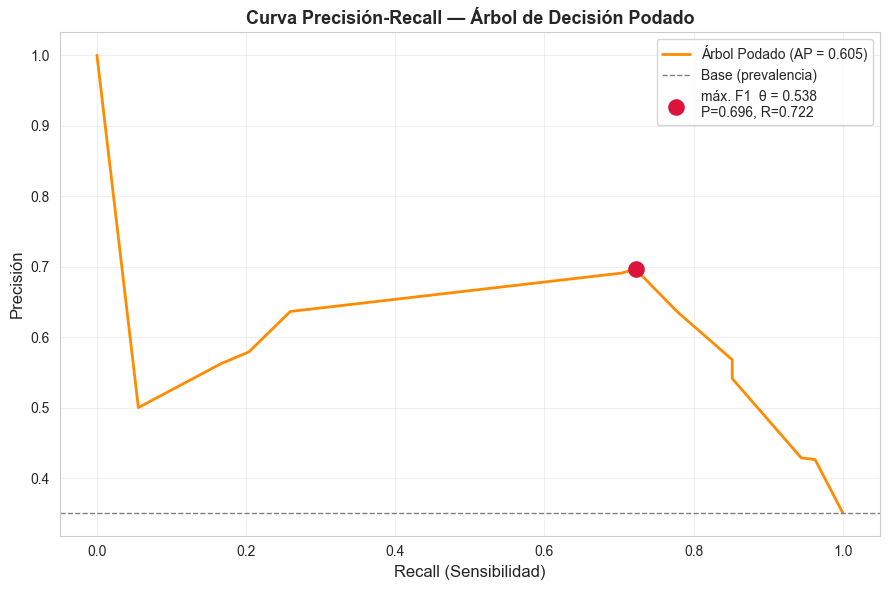


Barrido de Umbrales — Modelo Podado (conjunto de prueba):
----------------------------------------------------------------------


,Exactitud,Precisión,Recall,F1-Score,FN (perdidos),FP (falsas alarmas)
Umbral,,,,,,
0.200000,0.7208,0.5679,0.8519,0.6815,8,35
0.250000,0.7208,0.5679,0.8519,0.6815,8,35
0.300000,0.7662,0.6364,0.7778,0.7000,12,24
0.350000,0.7662,0.6364,0.7778,0.7000,12,24
0.400000,0.7662,0.6364,0.7778,0.7000,12,24
0.450000,0.7662,0.6364,0.7778,0.7000,12,24
0.500000,0.7922,0.6964,0.7222,0.7091,15,17
0.550000,0.7857,0.6909,0.7037,0.6972,16,17
0.600000,0.6883,0.6364,0.2593,0.3684,40,8


In [16]:
print("="*70)
print("CURVA PRECISIÓN-RECALL + BARRIDO DE UMBRAL")
print("="*70)

# ── Puntuaciones de probabilidad ─────────────────────────────────────
y_proba_pruned = dt_pruned.predict_proba(X_test)[:, 1]

# ── Curva Precisión-Recall ────────────────────────────────────────────
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_proba_pruned)
avg_precision = average_precision_score(y_test, y_proba_pruned)

# F1 en cada umbral de PR (ignorar el último punto donde el arreglo de recall tiene una entrada extra)
f1_curve = 2 * precision_curve[:-1] * recall_curve[:-1] / (
    precision_curve[:-1] + recall_curve[:-1] + 1e-9
)
best_pr_idx     = np.argmax(f1_curve)
best_thresh_pr  = pr_thresholds[best_pr_idx]

print(f"\nPrecisión Promedio (AP): {avg_precision:.4f}")
print(f"Umbral Óptimo (máx. F1): {best_thresh_pr:.4f}")
print(f"  → Precisión: {precision_curve[best_pr_idx]:.4f}")
print(f"  → Recall:    {recall_curve[best_pr_idx]:.4f}")
print(f"  → F1-Score:  {f1_curve[best_pr_idx]:.4f}")

# ── Graficar Curva PR ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(recall_curve, precision_curve, color="darkorange", lw=2,
        label=f"Árbol Podado (AP = {avg_precision:.3f})")
ax.axhline(y_test.mean(), color="gray", linestyle="--", lw=1, label="Base (prevalencia)")

ax.scatter(recall_curve[best_pr_idx], precision_curve[best_pr_idx],
           s=120, color="crimson", zorder=5,
           label=f"máx. F1  θ = {best_thresh_pr:.3f}\n"
                 f"P={precision_curve[best_pr_idx]:.3f}, R={recall_curve[best_pr_idx]:.3f}")

ax.set_xlabel("Recall (Sensibilidad)", fontsize=12)
ax.set_ylabel("Precisión", fontsize=12)
ax.set_title("Curva Precisión-Recall — Árbol de Decisión Podado", fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Tabla de Barrido de Umbrales ──────────────────────────────────────
print("\nBarrido de Umbrales — Modelo Podado (conjunto de prueba):")
print("-"*70)
sweep_thresholds = np.arange(0.20, 0.81, 0.05)
sweep_results = []

for t in sweep_thresholds:
    y_pred_t = (y_proba_pruned >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    prec_t   = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0.0
    rec_t    = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0.0
    f1_t     = 2 * prec_t * rec_t / (prec_t + rec_t) if (prec_t + rec_t) > 0 else 0.0
    acc_t    = (tp_t + tn_t) / len(y_test)
    sweep_results.append({
        'Umbral': round(t, 2),
        'Exactitud':  round(acc_t, 4),
        'Precisión': round(prec_t, 4),
        'Recall':    round(rec_t, 4),
        'F1-Score':  round(f1_t, 4),
        'FN (perdidos)': fn_t,
        'FP (falsas alarmas)': fp_t
    })

sweep_df = pd.DataFrame(sweep_results)

# Resaltar umbrales recomendados
display(
    sweep_df.set_index('Umbral').style
    .format("{:.4f}", subset=['Exactitud', 'Precisión', 'Recall', 'F1-Score'])
    .highlight_max(color="lightgreen",   subset=['Recall', 'F1-Score'])
    .set_caption("Green = más alto  |  Umbral predeterminado = 0.50")
)

APLICAR UMBRAL ÓPTIMO — COMPARACIÓN FINAL

Comparación de Estrategias de Umbral — Modelo Podado:
----------------------------------------------------------------------


,Umbral,Exactitud,Precisión,Recall,F1-Score,FN (perdidos),FP (falsas alarmas)
Estrategia,,,,,,,
Predeterminado (θ = 0.50),0.500000,0.7922,0.6964,0.7222,0.7091,15,17
máx. F1 (θ = 0.54),0.538000,0.7922,0.6964,0.7222,0.7091,15,17
Recall≥0.8 (θ = 0.25),0.254000,0.7208,0.5679,0.8519,0.6815,8,35


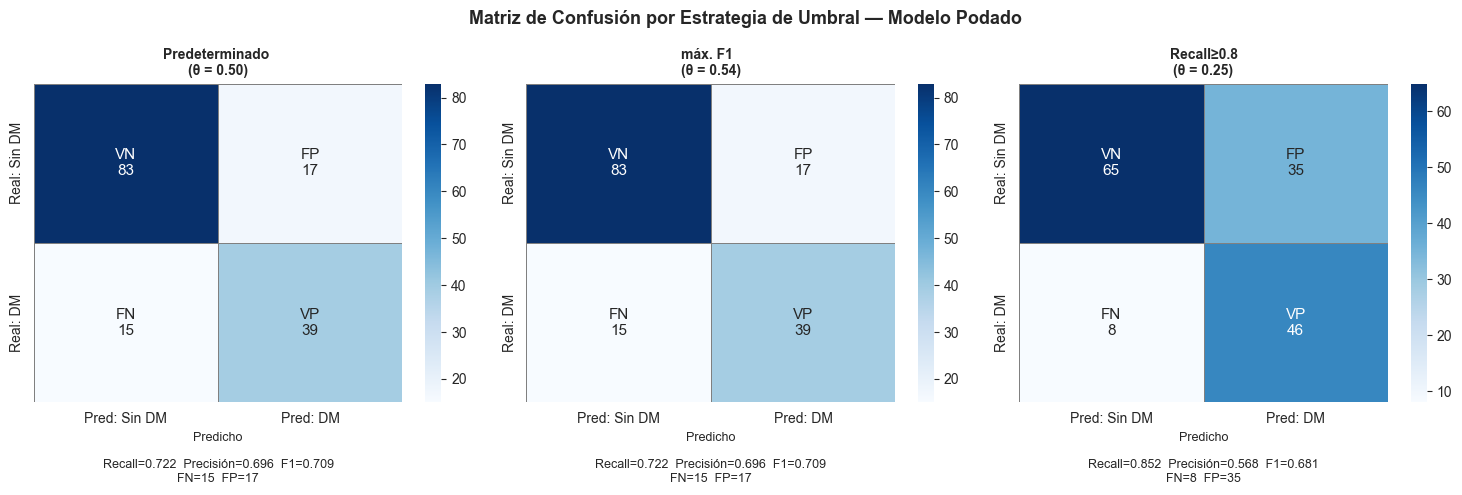


RECOMENDACIÓN (cribado médico — minimizar diagnósticos perdidos)

  Mejor estrategia : Recall≥0.8 (θ = 0.25)
  Umbral           : 0.254
  Recall           : 0.8519  ← maximizado
  Precisión        : 0.5679
  F1-Score         : 0.6815
  FN (perdidos)    : 8   ← minimizado
  FP (falsas al.)  : 35

  Disminuir el umbral aumenta la sensibilidad a costa de más
    falsas alarmas, lo cual es un compromiso aceptable para el cribado de primera línea.


In [17]:
print("="*70)
print("APLICAR UMBRAL ÓPTIMO — COMPARACIÓN FINAL")
print("="*70)

# ── Tres umbrales candidatos ──────────────────────────────────────────
# 1) Predeterminado     : 0.50
# 2) máx. F1            : penaliza FP y FN por igual  (de la curva PR)
# 3) Recall ≥ 0.80 con F1 más alto (prioridad de cribado médico)
recall_floor = 0.80
mask_high_recall = recall_curve[:-1] >= recall_floor
if mask_high_recall.any():
    best_recall_idx   = np.argmax(f1_curve[mask_high_recall])
    # mapear de vuelta al índice original
    orig_idx          = np.where(mask_high_recall)[0][best_recall_idx]
    best_thresh_recall = pr_thresholds[orig_idx]
else:
    best_thresh_recall = best_thresh_pr  # alternativa

candidates = {
    f"Predeterminado  (θ = 0.50)":                     0.50,
    f"máx. F1   (θ = {best_thresh_pr:.2f})":           best_thresh_pr,
    f"Recall≥{recall_floor} (θ = {best_thresh_recall:.2f})": best_thresh_recall,
}

comparison_rows = []
for label, thresh in candidates.items():
    y_pred_t = (y_proba_pruned >= thresh).astype(int)
    cm_t     = confusion_matrix(y_test, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    prec_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0.0
    rec_t  = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0.0
    f1_t   = 2 * prec_t * rec_t / (prec_t + rec_t) if (prec_t + rec_t) > 0 else 0.0
    acc_t  = (tp_t + tn_t) / len(y_test)
    comparison_rows.append({
        'Estrategia':          label,
        'Umbral':              round(thresh, 3),
        'Exactitud':           round(acc_t, 4),
        'Precisión':           round(prec_t, 4),
        'Recall':              round(rec_t, 4),
        'F1-Score':            round(f1_t, 4),
        'FN (perdidos)':       fn_t,
        'FP (falsas alarmas)': fp_t,
    })

comp_df = pd.DataFrame(comparison_rows)
print("\nComparación de Estrategias de Umbral — Modelo Podado:")
print("-"*70)
display(
    comp_df.set_index('Estrategia').style
    .format("{:.4f}", subset=['Exactitud', 'Precisión', 'Recall', 'F1-Score'])
    .highlight_max(color="lightgreen",   subset=['Recall', 'F1-Score'])
    .set_caption("Para cribado médico: minimizar FN (diabetes no detectada) → preferir filas con mayor Recall")
)

# ── Matrices de confusión en paralelo ────────────────────────────────
fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 5))

for ax, (label, thresh) in zip(axes, candidates.items()):
    y_pred_t = (y_proba_pruned >= thresh).astype(int)
    cm_t     = confusion_matrix(y_test, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    rec_t  = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0.0
    prec_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0.0
    f1_t   = 2 * prec_t * rec_t / (prec_t + rec_t) if (prec_t + rec_t) > 0 else 0.0

    cell_labels = np.array([
        [f"VN\n{tn_t}",  f"FP\n{fp_t}"],
        [f"FN\n{fn_t}",  f"VP\n{tp_t}"]
    ])
    sns.heatmap(cm_t, annot=cell_labels, fmt="", cmap="Blues",
                xticklabels=["Pred: Sin DM", "Pred: DM"],
                yticklabels=["Real: Sin DM", "Real: DM"],
                ax=ax, linewidths=0.5, linecolor="gray", annot_kws={"size": 11})
    ax.set_title(label.replace(" (", "\n("), fontsize=10, fontweight="bold")
    ax.set_xlabel(
        f"Predicho\n\nRecall={rec_t:.3f}  Precisión={prec_t:.3f}  F1={f1_t:.3f}\nFN={fn_t}  FP={fp_t}",
        fontsize=9
    )

plt.suptitle("Matriz de Confusión por Estrategia de Umbral — Modelo Podado", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Recomendación ────────────────────────────────────────────────────
# Determinar ganador por prioridad de Recall
best_row = comp_df.loc[comp_df['Recall'].idxmax()]
print("\n" + "="*70)
print("RECOMENDACIÓN (cribado médico — minimizar diagnósticos perdidos)")
print("="*70)
print(f"\n  Mejor estrategia : {best_row['Estrategia']}")
print(f"  Umbral           : {best_row['Umbral']:.3f}")
print(f"  Recall           : {best_row['Recall']:.4f}  ← maximizado")
print(f"  Precisión        : {best_row['Precisión']:.4f}")
print(f"  F1-Score         : {best_row['F1-Score']:.4f}")
print(f"  FN (perdidos)    : {int(best_row['FN (perdidos)'])}   ← minimizado")
print(f"  FP (falsas al.)  : {int(best_row['FP (falsas alarmas)'])}")
print(f"\n  Disminuir el umbral aumenta la sensibilidad a costa de más")
print(f"    falsas alarmas, lo cual es un compromiso aceptable para el cribado de primera línea.")

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

# Conclusiones

El árbol de decisión a utilizar para predecir la Diabetes es:

DecisionTreeClassifier con los parametros:
    max_depth=4,           # Limitar la profundidad del árbol
    min_samples_split=20,  # División conservadora
    min_samples_leaf=10,   # Cada predicción representa ≥10 pacientes
    random_state=42


Y utilizando el **umbral de 0.25** para predecir la diabetes, ya que tiene un mejor recall
consiguiendo **Recall -> 85%**

Es más importante detectar todos los posibles casos de diabetes. Se sacrifica algo de precisión (más falsos positivos) para asegurar que se minimizan los falsos negativos (diagnósticos de diabetes perdidos), lo cual es crítico en un contexto médico.
</div>